# Repeated Plateau Search Comparison

This notebook studies how the number of consecutive applications of `move_plateau` affects solution quality and runtime.

It produces two LaTeX tables:

1. mean relative solution quality after each application
2. mean cumulative runtime after each application

The analysis is grouped by graph type, size class, and density regime.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

The following configuration defines the analyzed step counts, numerical tolerance, result directories, and output directory.

In [2]:
MAX_STEPS = 10
REPEATED_PIPELINE = ",".join(["move_plateau"] * MAX_STEPS)
MOVE_STEPS = list(range(1, MAX_STEPS + 1))

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

RESULTS_DIR = Path("../results/experiment2/repeated_move")

STEP_RESULTS_FILE = RESULTS_DIR / "step_results.csv"

## Load and verify experiment data

Before the analysis, the notebook lists the contained pipelines, start partitions, zero-gain factors, number of runs, and number of recorded steps. This provides a compact check that the intended experiment results were loaded.

In [3]:
step_all = pd.read_csv(STEP_RESULTS_FILE)

required_columns = {
    "experiment",
    "pipeline",
    "start_partition",
    "zero_gain_factor",
    "run",
    "graph_type",
    "size_class",
    "regime",
    "dataset",
    "instance",
    "step_index",
    "step_name",
    "score_after",
    "runtime",
}

missing_columns = required_columns.difference(step_all.columns)

if missing_columns:
    raise ValueError("Missing required columns: " + ", ".join(sorted(missing_columns)))

experiment_check = (
    step_all
    .groupby(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        num_runs=("run", "nunique"),
        num_instances=("instance", "nunique"),
        num_steps=("step_index", "nunique"),
        num_rows=("run", "size"),
    )
    .sort_values(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        na_position="first",
    )
    .reset_index(drop=True)
)

print(f"Loaded {len(step_all):,} rows from {STEP_RESULTS_FILE}")

experiment_check

Loaded 1,600,000 rows from ../results/experiment2_new/repeated_move/step_results.csv


,pipeline,start_partition,zero_gain_factor,num_runs,num_instances,num_steps,num_rows
0,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_first_matching,2,10,2000,10,200000
1,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_product_matching,2,10,2000,10,200000
2,"move_plateau,move_plateau,move_plateau,move_pl...",kapoce,2,10,2000,10,200000
3,"move_plateau,move_plateau,move_plateau,move_pl...",leiden_mdgp,2,10,2000,10,200000
4,"move_plateau,move_plateau,move_plateau,move_pl...",matching,2,10,2000,10,200000
5,"move_plateau,move_plateau,move_plateau,move_pl...",maximum_matching,2,10,2000,10,200000
6,"move_plateau,move_plateau,move_plateau,move_pl...",maximum_matching_edge_cover,2,10,2000,10,200000
7,"move_plateau,move_plateau,move_plateau,move_pl...",singleton,2,10,2000,10,200000


## Prepare repeated plateau results

Only the pipeline containing exactly ten consecutive applications of `move_plateau` is retained. The step index is converted from zero-based indexing to application numbers from 1 to 10.

In [4]:
step_all["dataset_group"] = (
        step_all["size_class"].astype(str)
        + " "
        + step_all["regime"].astype(str)
)

step_all["graph_type"] = pd.Categorical(
    step_all["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

step_all["dataset_group"] = pd.Categorical(
    step_all["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

plateau_step_results = step_all[
    (step_all["pipeline"] == REPEATED_PIPELINE)
    & (step_all["step_name"] == "move_plateau")
].copy()

if plateau_step_results.empty:
    raise ValueError(f"No rows found for the expected repeated pipeline: {REPEATED_PIPELINE}")

plateau_step_results["step_number"] = plateau_step_results["step_index"] + 1
observed_steps = sorted(plateau_step_results["step_number"].unique())

if observed_steps != MOVE_STEPS:
    raise ValueError(f"Expected steps {MOVE_STEPS}, but found {observed_steps}.")

## Solution quality

For every instance and application number, the best result across all randomized runs and start partitions is retained.

The result after ten applications is used as the reference. Relative solution quality after application $k$ is defined as

$
\frac{\text{score after application }10}
     {\text{score after application }k}.
$

A value of $1.0$ means that the result already matches the best result obtained after ten applications. Values greater than $1.0$ indicate the remaining quality gap.

In [5]:
best_run_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "step_number",
]

best_runs_per_step = (
    plateau_step_results
    .sort_values(
        [
            "score_after",
            "runtime",
            "run",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .groupby(
        best_run_keys,
        observed=True,
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)

In [6]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

step_scores = (
    best_runs_per_step
    .pivot(
        index=instance_keys,
        columns="step_number",
        values="score_after",
    )
)

step_scores.columns.name = None

if step_scores.isna().any().any():
    incomplete_instances = step_scores[step_scores.isna().any(axis=1)]
    raise ValueError(f"{len(incomplete_instances)} instances do not contain results for every plateau application.")

In [7]:
reference_score = step_scores[MAX_STEPS]

relative_quality = step_scores.rdiv(reference_score, axis=0)
relative_quality.columns.name = "step_number"

relative_quality_summary = (
    relative_quality
    .groupby(
        level=["graph_type", "dataset_group"]
    )
    .mean()
    .stack()
    .rename("mean_relative_quality")
    .reset_index()
)

relative_quality_summary

,graph_type,dataset_group,step_number,mean_relative_quality
0,powerlaw,small sparse,1,1.001085
1,powerlaw,small sparse,2,1.000236
2,powerlaw,small sparse,3,1.000089
3,powerlaw,small sparse,4,1.000050
4,powerlaw,small sparse,5,1.000024
...,...,...,...,...
75,er,large dense,6,1.003848
76,er,large dense,7,1.002857
77,er,large dense,8,1.001906
78,er,large dense,9,1.000912


## Relative solution quality by dataset group

The following plots show the mean relative solution quality after each number of consecutive `move_plateau` applications.

A value of 1.0 indicates that the result matches the best solution obtained after ten applications. Values above 1.0 show the remaining quality gap.

In [8]:
DATASET_LABELS = {
    "large dense": "large dense",
    "large sparse": "large sparse",
    "small dense": "small dense",
    "small sparse": "small sparse",
}

GRAPH_TYPE_LABELS = {
    "er": "Erdős–Rényi",
    "powerlaw": "Powerlaw",
}

In [9]:
def plot_relative_quality(summary: pd.DataFrame, graph_type: str, output_path: str | None = None) -> None:
    graph_data = (
        summary[summary["graph_type"] == graph_type]
        .sort_values(["dataset_group", "step_number"])
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group",observed=True):
        ax.plot(
            group_data["step_number"],
            group_data["mean_relative_quality"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="10 Anwendungen",
    )

    ax.set_xlabel(r"Anzahl aufeinanderfolgender Anwendungen von move_plateau")
    ax.set_ylabel("Mittlere relative Lösungsqualität")
    ax.set_title(f"Relative Lösungsqualität ({GRAPH_TYPE_LABELS[graph_type]})")

    ax.set_xticks(MOVE_STEPS)
    ax.set_ylim(
        graph_data["mean_relative_quality"].min() - 0.0005,
        graph_data["mean_relative_quality"].max() + 0.0005,
    )

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

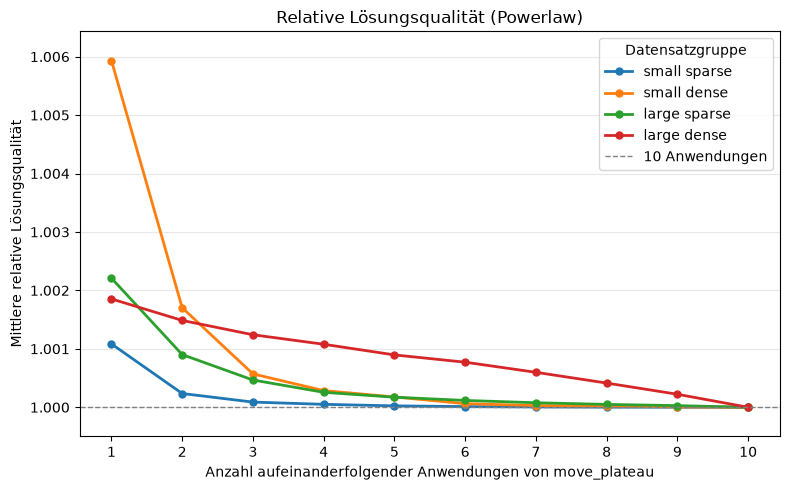

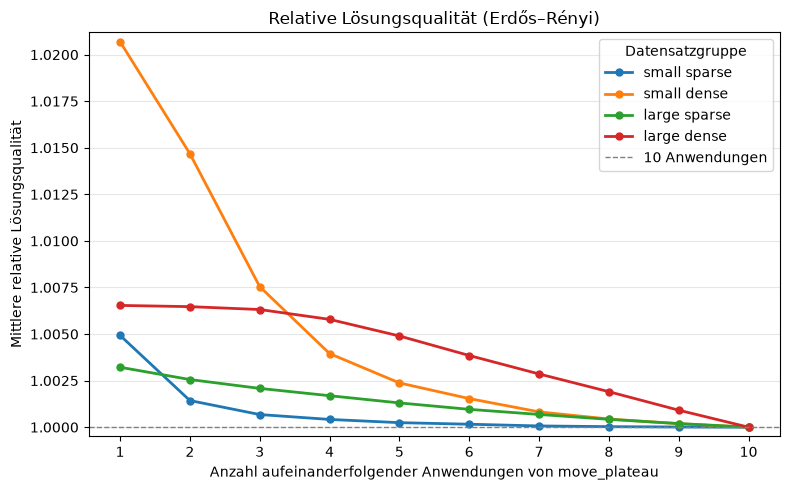

In [10]:
plot_relative_quality(
    relative_quality_summary,
    "powerlaw",
    "../results/plots/powerlaw_plateau_search_quality.png"
)

plot_relative_quality(
    relative_quality_summary,
    "er",
    "../results/plots/er_plateau_search_quality.png"
)

## Runtime

For each instance and step number, the start partition of the best-performing run is selected. For this selected start partition, the step runtimes are accumulated separately within every randomized run.

The cumulative runtimes of all runs using the selected start partition are then summed. Finally, these total runtimes are averaged over all instances in the corresponding graph and dataset group.

In [11]:
trajectory_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "experiment",
    "start_partition",
    "pipeline",
    "zero_gain_factor",
    "run",
]

configuration_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "step_number",
    "experiment",
    "start_partition",
    "pipeline",
    "zero_gain_factor",
]

plateau_step_results_with_runtime = (
    plateau_step_results
    .sort_values(
        trajectory_keys + ["step_number"]
    )
    .copy()
)

plateau_step_results_with_runtime[
    "cumulative_runtime"
] = (
    plateau_step_results_with_runtime
    .groupby(
        trajectory_keys,
        observed=True,
        dropna=False,
    )["runtime"]
    .cumsum()
)

winning_configurations = best_runs_per_step[configuration_keys].drop_duplicates()

winning_runtimes = (
    plateau_step_results_with_runtime
    .merge(
        winning_configurations,
        on=configuration_keys,
        how="inner",
        validate="many_to_one",
    )
)

runtime_per_instance = (
    winning_runtimes
    .groupby(
        best_run_keys,
        observed=True,
    )
    .agg(
        total_cumulative_runtime=(
            "cumulative_runtime",
            "sum",
        ),
        num_runs=("run", "nunique"),
    )
    .reset_index()
)

runtime_summary = (
    runtime_per_instance
    .groupby(
        [
            "graph_type",
            "dataset_group",
            "step_number",
        ],
        observed=True,
    )
    .agg(
        mean_total_runtime=(
            "total_cumulative_runtime",
            "mean",
        )
    )
    .reset_index()
)

runtime_summary

,graph_type,dataset_group,step_number,mean_total_runtime
0,powerlaw,small sparse,1,1.302341
1,powerlaw,small sparse,2,3.107945
2,powerlaw,small sparse,3,5.118681
3,powerlaw,small sparse,4,7.223712
4,powerlaw,small sparse,5,9.276982
...,...,...,...,...
75,er,large dense,6,1714.454864
76,er,large dense,7,1952.349296
77,er,large dense,8,2170.495736
78,er,large dense,9,2308.541532


### Visualize the runtime development

The following figures show the mean total runtime of all randomized runs after
each number of consecutive `move_plateau` applications.

Separate figures are generated for Erdős–Rényi and Powerlaw graphs. The figure
labels are given in German because the plots are intended for inclusion in the
thesis.

In [12]:
def plot_total_runtime(summary: pd.DataFrame, graph_type: str, output_path: str | None = None) -> None:
    graph_data = (
        summary[summary["graph_type"] == graph_type]
        .sort_values(["dataset_group", "step_number"])
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["step_number"],
            group_data["mean_total_runtime"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    graph_label = GRAPH_TYPE_LABELS.get(graph_type, graph_type)

    ax.set_xlabel("Anzahl aufeinanderfolgender Anwendungen von move_plateau")
    ax.set_ylabel("Mittlere Gesamtlaufzeit der zehn Runs (s)")
    ax.set_title(f"Gesamtlaufzeit ({graph_label})")

    ax.set_xticks(MOVE_STEPS)

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()

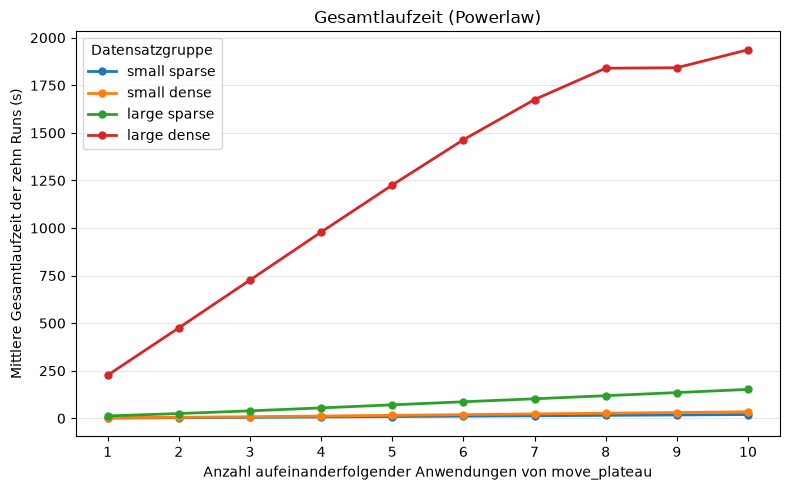

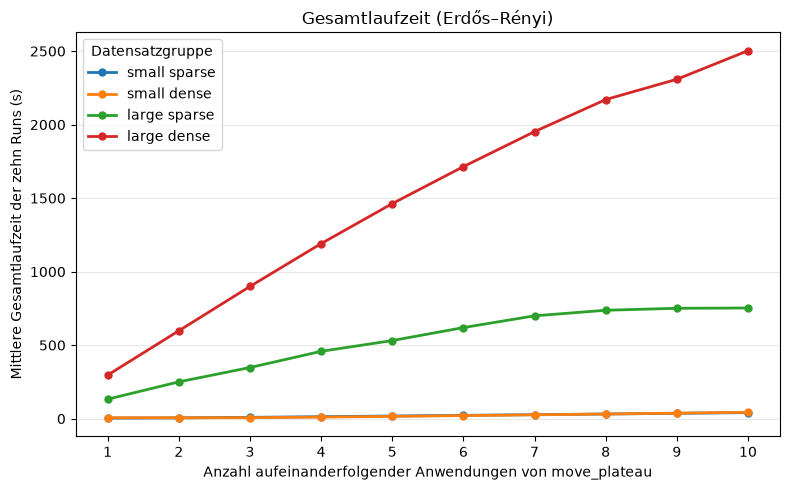

In [13]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    "../results/plots/powerlaw_plateau_search_runtime.png"
)

plot_total_runtime(
    runtime_summary,
    "er",
    "../results/plots/er_plateau_search_runtime.png"
)

## Combined comparison data

In [14]:
comparison_summary = (
    relative_quality_summary
    .merge(
        runtime_summary,
        on=[
            "graph_type",
            "dataset_group",
            "step_number",
        ],
    )
)

comparison_summary["step_number"] = pd.Categorical(
    comparison_summary["step_number"],
    categories=MOVE_STEPS,
    ordered=True,
)

comparison_summary = (
    comparison_summary
    .sort_values(
        [
            "graph_type",
            "dataset_group",
            "step_number",
        ]
    )
    .reset_index(drop=True)
)

comparison_summary

,graph_type,dataset_group,step_number,mean_relative_quality,mean_total_runtime
0,powerlaw,small sparse,1,1.001085,1.302341
1,powerlaw,small sparse,2,1.000236,3.107945
2,powerlaw,small sparse,3,1.000089,5.118681
3,powerlaw,small sparse,4,1.000050,7.223712
4,powerlaw,small sparse,5,1.000024,9.276982
...,...,...,...,...,...
75,er,large dense,6,1.003848,1714.454864
76,er,large dense,7,1.002857,1952.349296
77,er,large dense,8,1.001906,2170.495736
78,er,large dense,9,1.000912,2308.541532
